In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import  DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix
)

In [2]:
df = pd.read_csv('customer_churn_dataset-training-master.csv')

print('Dataset Shape:')
print(df.shape)

print('\nFirst 5 rows:')
df.head()

Dataset Shape:
(440833, 12)

First 5 rows:


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


## EDA

In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,440832.0,NaN,NaN,NaN,225398.667955,129531.91855,2.0,113621.75,226125.5,337739.25,449999.0
Age,440832.0,NaN,NaN,NaN,39.373153,12.442369,18.0,29.0,39.0,48.0,65.0
Gender,440832,2,Male,250252,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenure,440832.0,NaN,NaN,NaN,31.256336,17.255727,1.0,16.0,32.0,46.0,60.0
Usage Frequency,440832.0,NaN,NaN,NaN,15.807494,8.586242,1.0,9.0,16.0,23.0,30.0
Support Calls,440832.0,NaN,NaN,NaN,3.604437,3.070218,0.0,1.0,3.0,6.0,10.0
Payment Delay,440832.0,NaN,NaN,NaN,12.965722,8.258063,0.0,6.0,12.0,19.0,30.0
Subscription Type,440832,3,Standard,149128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Contract Length,440832,3,Annual,177198,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Spend,440832.0,NaN,NaN,NaN,631.616223,240.803001,100.0,480.0,661.0,830.0,1000.0


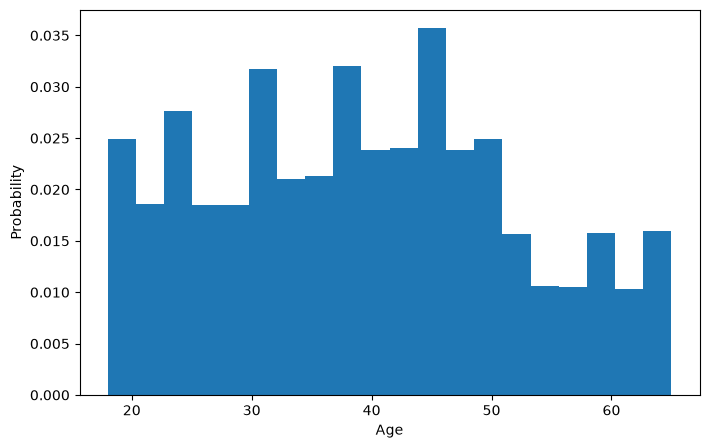

In [4]:
fig , ax = plt.subplots(figsize=(8,5))
ax.hist(
    df['Age'], bins=20, density=True
)
ax.set_xlabel('Age')
ax.set_ylabel('Probability')
plt.show()

#### <b> Age Distribution Observation </b>

The age distribution shows an unusual increase at Age = 65, where the number of observations is significantly higher than other ages. This suggests that 65 may represent a grouped value rather than only people who are exactly 65 years old.

A possible explanation is top-coding, where all ages above a certain threshold (e.g., 65+) are recorded as 65. Therefore, this value should be treated carefully during analysis and modeling, as it may represent a range of ages rather than a single age group.

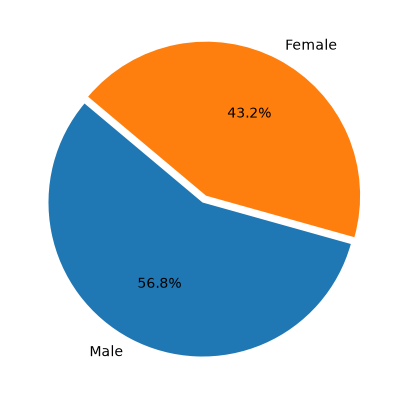

In [5]:
df_gender = df['Gender'].value_counts().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))

ax.pie(df_gender['count'], labels=df_gender['Gender'],autopct='%1.1f%%', startangle=140, explode=[0,0.05])
plt.show()

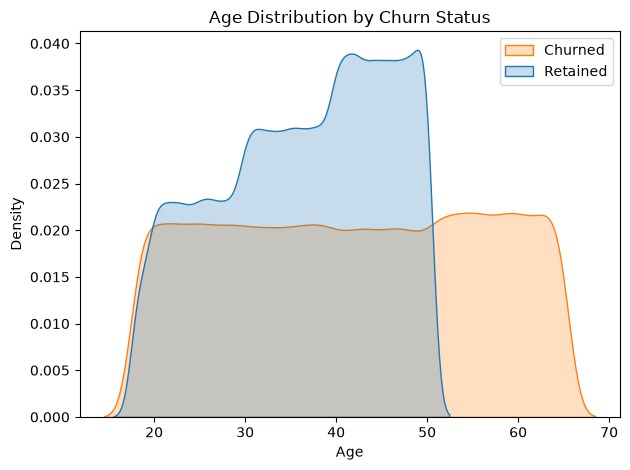

In [6]:
plt.Figure(figsize=(12,6))
sns.kdeplot(data=df, x='Age', hue='Churn', fill=True, common_norm=False)
plt.title('Age Distribution by Churn Status')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(labels=['Churned', 'Retained'])
plt.tight_layout()
plt.show()

In [7]:
df['Age_Group'] = pd.cut(df['Age'],
                        bins=[10,20,30,40,50,60,70],
                        labels=['10-20','20-30','30-40','40-50','50-60', '60-70'])
age_churn_rate = df.groupby(['Age_Group']).agg({'Churn':'mean', 'CustomerID':'count'})
age_churn_rate.rename(columns={'Churn':'Churn_Rate', 'CustomerID':'#Customer'}, inplace=True)
age_churn_rate

,Churn_Rate,#Customer
Age_Group,,
10-20,0.605494,25845
20-30,0.531868,97088
30-40,0.457783,111472
40-50,0.400952,124773
50-60,1.000000,54443
60-70,1.000000,27211


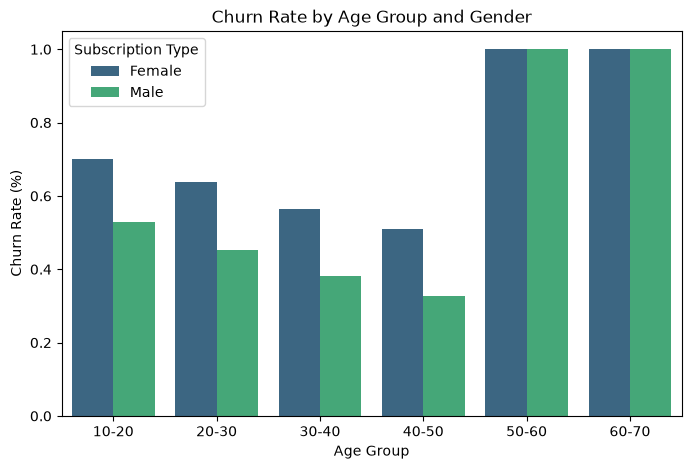

In [8]:
age_gender_churn_rate = df.groupby(['Age_Group', 'Gender']).agg({'Churn':'mean', 'CustomerID':'count'}).reset_index()
age_gender_churn_rate.rename(columns={'Churn':'Churn_Rate', 'CustomerID':'#Customer'}, inplace=True)


plt.figure(figsize=(8, 5))
sns.barplot(x='Age_Group', y='Churn_Rate', hue='Gender', data=age_gender_churn_rate, palette='viridis')
plt.title('Churn Rate by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.legend(title='Subscription Type')
plt.show()

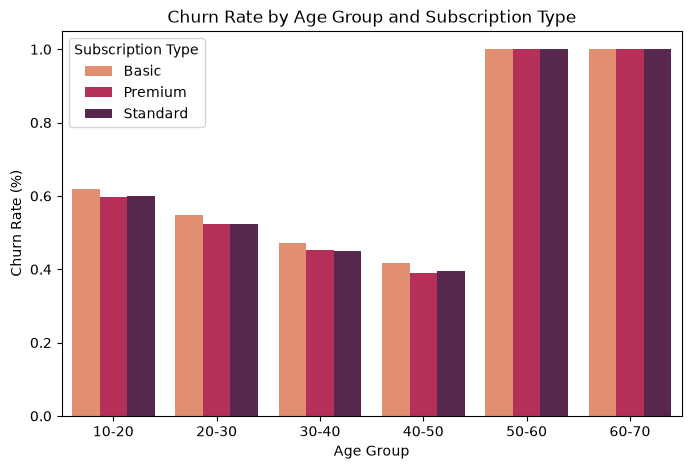

In [9]:
age_gender_churn_rate = df.groupby(['Age_Group', 'Subscription Type']).agg({'Churn':'mean', 'CustomerID':'count'}).reset_index()
age_gender_churn_rate.rename(columns={'Churn':'Churn_Rate', 'CustomerID':'#Customer'}, inplace=True)


plt.figure(figsize=(8, 5))
sns.barplot(x='Age_Group', y='Churn_Rate', hue='Subscription Type', data=age_gender_churn_rate, palette='rocket_r')
plt.title('Churn Rate by Age Group and Subscription Type')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.legend(title='Subscription Type')
plt.show()

In [10]:
## Explore Tenure
df['Tenure'].describe()

count    440832.000000
mean         31.256336
std          17.255727
min           1.000000
25%          16.000000
50%          32.000000
75%          46.000000
max          60.000000
Name: Tenure, dtype: float64

In [11]:
df['Tenure_Group'] = pd.cut(df['Tenure'],
                            bins = [10,20,30,40,50,60],
                            labels=['10-20', '20-30', '30-40', '40-50', '50-60'])
tenure_churn_rate = df.groupby(['Tenure_Group']).agg({'Churn':'mean', 'CustomerID':'count'})

tenure_churn_rate.rename(columns={'Churn':'Churn_Rate', 'CustomerID':'#Customers'}, inplace=True)
tenure_churn_rate

,Churn_Rate,#Customers
Tenure_Group,,
10-20,0.621662,67585
20-30,0.575352,72234
30-40,0.540703,76308
40-50,0.539975,76998
50-60,0.544432,76882


## Preprocessing

In [12]:
print('\nMissing values:')
print(df.isnull().sum())

print('\nTarget distribution:')
print(df['Churn'].value_counts(normalize=True))


Missing values:
CustomerID               1
Age                      1
Gender                   1
Tenure                   1
Usage Frequency          1
Support Calls            1
Payment Delay            1
Subscription Type        1
Contract Length          1
Total Spend              1
Last Interaction         1
Churn                    1
Age_Group                1
Tenure_Group         70826
dtype: int64

Target distribution:
Churn
1.0    0.567107
0.0    0.432893
Name: proportion, dtype: float64


In [13]:
print(df.__len__())
df = df.dropna()

## Drop CustomerID
df = df.drop(columns=['CustomerID'])
print(df.__len__())



440833
370007


In [14]:

lbe_gender = LabelEncoder()
lbe_gender.fit(df['Gender'].drop_duplicates())
df['Gender'] = lbe_gender.transform(df['Gender'])

lbe_subscriptiontype = LabelEncoder()
lbe_subscriptiontype.fit(df['Subscription Type'].drop_duplicates())
df['Subscription Type'] = lbe_subscriptiontype.transform(df['Subscription Type'])


lbe_Contract = LabelEncoder()
lbe_Contract.fit(df['Contract Length'].drop_duplicates())

df['Contract Length'] = lbe_Contract.transform(df['Contract Length'])

In [15]:
df.drop(columns=['Tenure_Group', 'Age_Group'], inplace=True)
corr = df.corr()['Churn'].sort_values(ascending=True).reset_index()
corr.rename(columns={'Churn':'Corr', 'index':'Feature'}, inplace=True)
corr = corr.drop(corr[corr['Feature']=='Churn'].index)
corr

,Feature,Corr
0,Total Spend,-0.430871
1,Gender,-0.175564
2,Usage Frequency,-0.054319
3,Tenure,-0.052955
4,Contract Length,-0.001301
5,Subscription Type,0.002277
6,Last Interaction,0.150408
7,Age,0.219333
8,Payment Delay,0.312639
9,Support Calls,0.576117


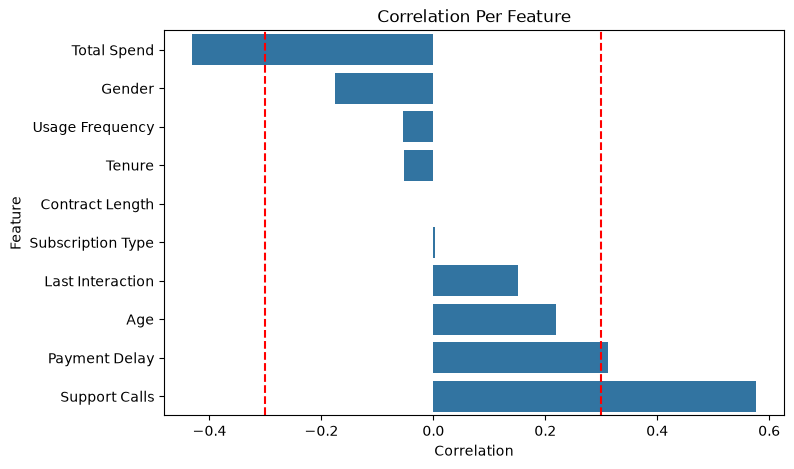

In [16]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Corr', y='Feature', data=corr)
plt.title('Correlation Per Feature')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.axvline(x=0.3, color='r', linestyle='--', label = 'Highly Correlation Threshold')
plt.axvline(x=-0.3, color='r', linestyle='--')
plt.show()

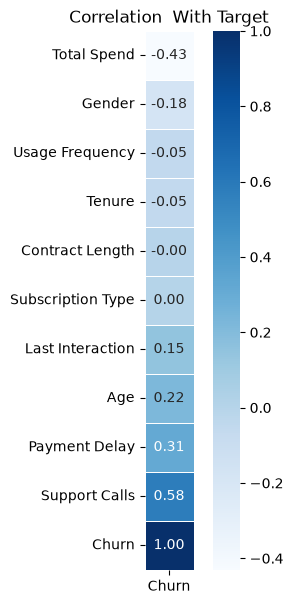

In [17]:
corr_with_target = df.corr()['Churn'].sort_values(ascending=True)
plt.figure(figsize=(5,7))
sns.heatmap(
    data=pd.DataFrame(corr_with_target),
    annot=True,          
    fmt=".2f",           
    cmap="Blues",       
    cbar=True,           
    linewidths=0.5,      
    linecolor='white',  
    square=True         
)

plt.title("Correlation  With Target", fontsize=12)
plt.show()

In [18]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)

print(X_test.shape)

(296005, 10)
(74002, 10)


In [21]:
columns_to_scale = ['Age',  'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay','Total Spend',
       'Last Interaction']
scaler = StandardScaler()
X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

Logistic Regression (Acc : 0.85)
              precision    recall  f1-score   support

         0.0       0.82      0.85      0.83     32281
         1.0       0.88      0.85      0.87     41721

    accuracy                           0.85     74002
   macro avg       0.85      0.85      0.85     74002
weighted avg       0.85      0.85      0.85     74002



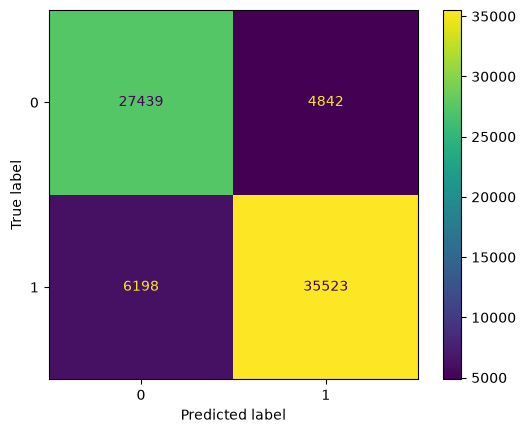

Naive Bayes (Acc : 0.91)
              precision    recall  f1-score   support

         0.0       0.87      0.94      0.90     32281
         1.0       0.95      0.89      0.92     41721

    accuracy                           0.91     74002
   macro avg       0.91      0.91      0.91     74002
weighted avg       0.91      0.91      0.91     74002



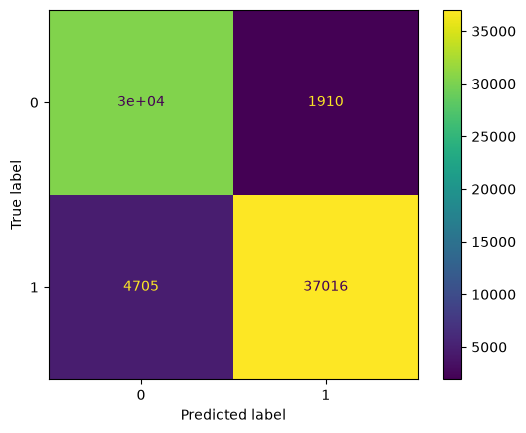

KNN (Acc : 0.96)
              precision    recall  f1-score   support

         0.0       0.91      1.00      0.95     32281
         1.0       1.00      0.93      0.96     41721

    accuracy                           0.96     74002
   macro avg       0.96      0.96      0.96     74002
weighted avg       0.96      0.96      0.96     74002



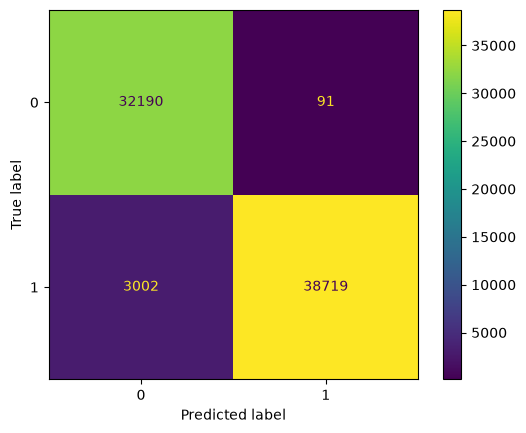

Decision Tree (Acc : 1.00)
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     32281
         1.0       1.00      1.00      1.00     41721

    accuracy                           1.00     74002
   macro avg       1.00      1.00      1.00     74002
weighted avg       1.00      1.00      1.00     74002



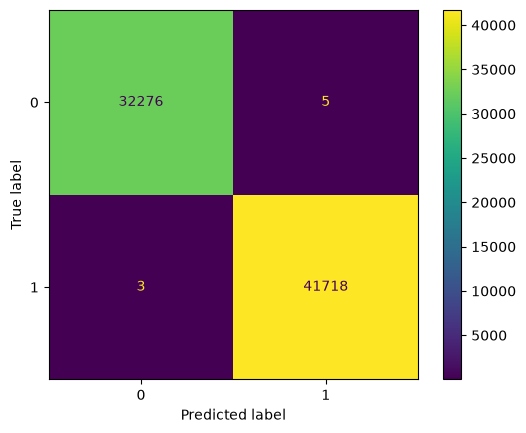

Random Forest (Acc : 1.00)
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     32281
         1.0       1.00      1.00      1.00     41721

    accuracy                           1.00     74002
   macro avg       1.00      1.00      1.00     74002
weighted avg       1.00      1.00      1.00     74002



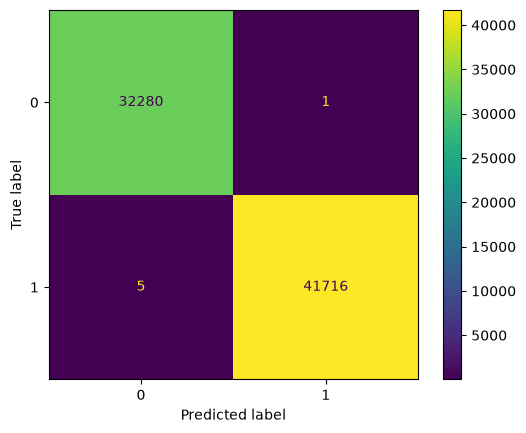

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.850815,0.880045,0.851442
1,Naive Bayes,0.910611,0.950933,0.887227
2,KNN,0.958204,0.997655,0.928046
3,Decision Tree,0.999892,0.999880,0.999928
4,Random Forest,0.999919,0.999976,0.999880


In [27]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    })

    print(f"{name} (Acc : {accuracy_score(y_test, y_pred):.2f})")
    print("=========================")
    print(classification_report(y_test, y_pred))
    cm  = confusion_matrix(y_test, y_pred)
    plot = ConfusionMatrixDisplay(confusion_matrix= cm)
    plot.plot()
    plt.show()

results_df = pd.DataFrame(results)
results_df
    